# GET 324: INTRODUCTION TO ARTIFICIAL INTELLIGENCE, MACHINE LEARNING AND CONVERGENT TECHNOLOGIES 
# MINI-PROJECT: CLOUD COMPUTING AND AI MODEL DEPLOYMENT FOR ENGINEERING APPLICATIONS
# GROUP CE5: SKIN CANCER (MALIGNANT VS BENING)

#

# STEP 1: Import Libraries  

In [74]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)


# STEP 2: Set Random Seeds

In [75]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to : {SEED}')


TensorFlow version : 2.21.0
Random seed set to : 42


# STEP 3: Results Directory

In [76]:
results_dir = "results/mini_project/"

if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

os.makedirs("models", exist_ok=True)


# STEP 4: Check for GPU Availability

In [77]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'\nGPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('\nNo GPU found — training will run on CPU (slower).')



No GPU found — training will run on CPU (slower).


# STEP 5: Configure the dataset paths

In [78]:
TRAIN_DIR = r"C:\Users\HP\Desktop\GET_324\Notebooks\Mini-Project Dataset\train"
TEST_DIR = r"C:\Users\HP\Desktop\GET_324\Notebooks\Mini-Project Dataset\test"

# STEP 6: Confirm the directories exist

In [79]:
for split, d in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    exists = os.path.exists(d)
    count = 0
    if exists:
        for cls in os.listdir(d):
            cls_path = os.path.join(d, cls)
            if os.path.isdir(cls_path):
                count += len(os.listdir(cls_path))
    print(f'{split:>5} dir exists={exists} images≈{count}')


train dir exists=True images≈2637
 test dir exists=True images≈660


# STEP 7: Set Global Hyperparameters

In [80]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 30            
LR = 1e-3             

print(f'Image size  : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Max epochs  : {EPOCHS}')
print(f'Learning rate: {LR}')

Image size  : 224 x 224
Batch size  : 32
Max epochs  : 30
Learning rate: 0.001


# STEP 8: Load the training dataset with image_dataset_from_directory

In [81]:
train_dataset = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR, validation_split=0.2, subset="training", image_size=(IMAGE_HEIGHT, IMAGE_WIDTH), batch_size=BATCH_SIZE, seed=SEED, shuffle=True,)

Found 2637 files belonging to 2 classes.
Using 2110 files for training.


# STEP 9: Load the validation dataset with image_dataset_from_directory

In [82]:
val_dataset = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR, validation_split=0.2, subset="validation", image_size=(IMAGE_HEIGHT, IMAGE_WIDTH), batch_size=BATCH_SIZE, seed=SEED, shuffle=False,)

Found 2637 files belonging to 2 classes.
Using 527 files for validation.


# STEP 10: Load the test dataset with image_dataset_from_directory

In [83]:
test_dataset = tf.keras.utils.image_dataset_from_directory(TEST_DIR, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH), batch_size=BATCH_SIZE, seed=SEED, shuffle=False,)

Found 660 files belonging to 2 classes.


# STEP 11: Get class names and number of classes

In [84]:
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')

Classes (2): ['benign', 'malignant']


# STEP 12: Check class balance

Train class counts: {'benign': 1440, 'malignant': 1197}


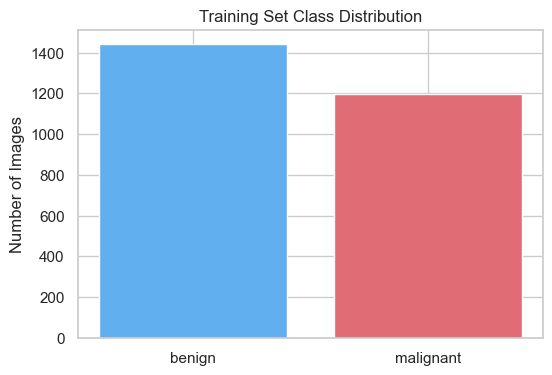

In [85]:
train_counts = {}
for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        train_counts[cls] = len(os.listdir(cls_path))
print('Train class counts:', train_counts)

plt.figure(figsize=(6, 4))
plt.bar(train_counts.keys(), train_counts.values(), color=['#61afef', '#e06c75'])
plt.title('Training Set Class Distribution')
plt.ylabel('Number of Images')
plt.savefig(results_dir + 'class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# STEP 13: Sanity-Check (visualise dataset samples)

In [86]:
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

# STEP 14: Visualise the first 16 images and their labels

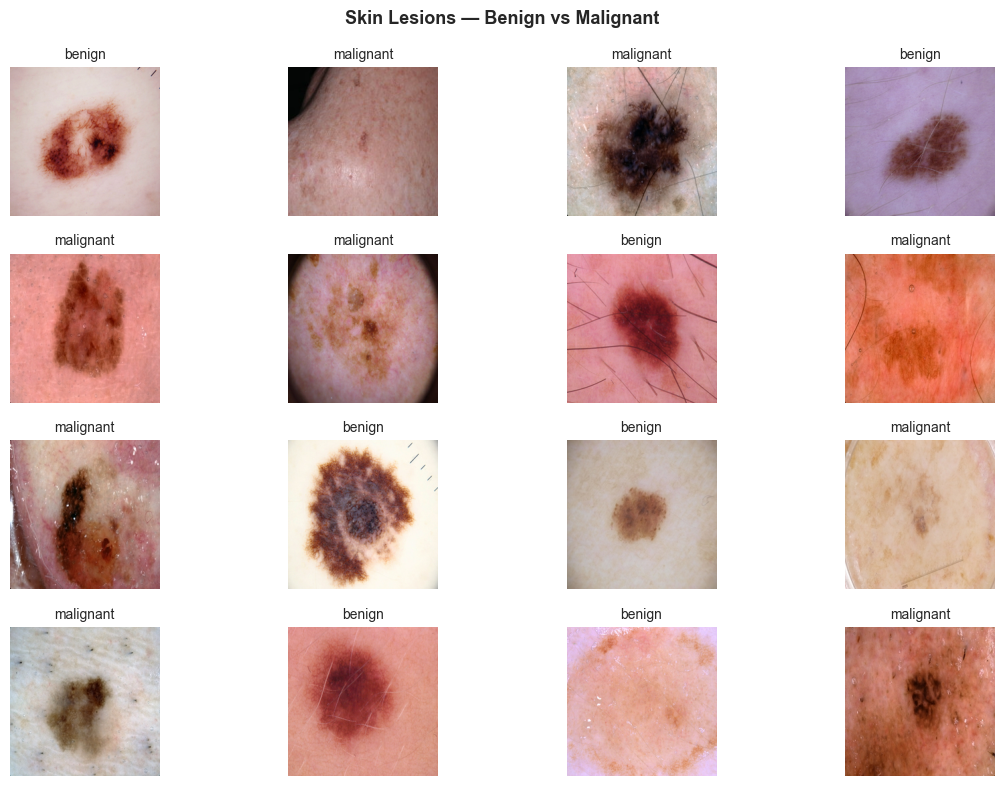

In [87]:
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(class_names[fixed_labels[i]], fontsize=10)
    plt.axis('off')
plt.suptitle('Skin Lesions — Benign vs Malignant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir + 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

# STEP 15: Optimise the data pipeline

In [88]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE))
val_dataset = (val_dataset.cache().prefetch(buffer_size=AUTOTUNE))
test_dataset = (test_dataset.cache().prefetch(buffer_size=AUTOTUNE))
print('Pipeline optimised with cache + shuffle + prefetch.')

Pipeline optimised with cache + shuffle + prefetch.


# STEP 16: Define the data augmentation pipeline

In [89]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
], name='data_augmentation')

# STEP 17: Visualise augmentation effects on one image

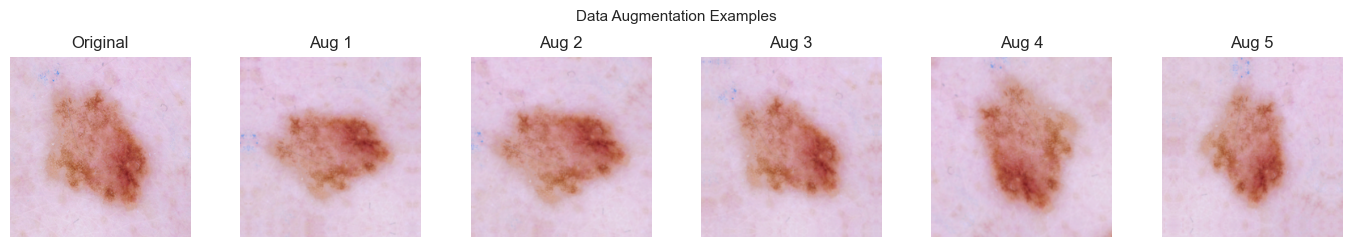

In [90]:
for images, _ in train_dataset.take(1):
    sample = images[0:1]  # shape (1, H, W, 3)
    break

fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 6):
    aug_img = data_augmentation(sample, training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig(results_dir + 'augmentation_examples.png', dpi=120, bbox_inches='tight')
plt.show()

# STEP 18: Define shared callbacks and utilities

In [91]:
def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'models/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1,
        ),
    ]


def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(results_dir + f'{title.lower().replace(" ", "_")}_curves.png',
                dpi=120, bbox_inches='tight')
    plt.show()


In [92]:
def evaluate_model(model, dataset, class_names, title='Model', results_dir=results_dir):
    """Evaluate a binary skin-lesion classification model."""
    y_true, y_pred, y_prob = [], [], []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f'\n{title}')
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'Recall   : {recall_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred, average="weighted"):.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, annot_kws={'fontsize': 11, 'fontweight': 'bold'} )
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(results_dir + f'{title.lower().replace(" ", "_")}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()

    malignant_idx = class_names.index('malignant') if 'malignant' in class_names else 1
    benign_idx = 1 - malignant_idx

    fn = cm[malignant_idx][benign_idx]       # malignant misclassified as benign
    tp = cm[malignant_idx][malignant_idx]
    fp = cm[benign_idx][malignant_idx]       # benign misclassified as malignant
    tn = cm[benign_idx][benign_idx]

    fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')
    fpr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')

    print(f'False Negative Rate (FNR): {fnr:.4f}')
    print(f'False Positive Rate (FPR): {fpr:.4f}')

    return accuracy_score(y_true, y_pred), fnr

print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


# STEP 19: Build the Custom CNN Architecture

In [93]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
OUTPUTS = num_classes

def build_custom_cnn(input_shape, augmentation):
    """
    A three-block CNN built entirely from scratch.
    Filters double each block (32 -> 64 -> 128) following a standard design
    pattern. Augmentation is embedded inside the model so it runs
    automatically during training.
    """
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)
    
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name='custom_cnn')

cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 56, 56, 128)         │             5

 Total params: 322,338 (1.23 MB)

 Trainable params: 321,442 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

# STEP 20: Compile the custom CNN model

In [95]:
cnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'],)

# STEP 21: Train the model

In [101]:
cnn_history = cnn_model.fit( train_dataset, validation_data=val_dataset, epochs=EPOCHS, callbacks=make_callbacks('custom_cnn'), verbose=1)

Epoch 1/30


C:\Users\HP\anaconda4\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


66/66 ━━━━━━━━━━━━━━━━━━━━ 471s 7s/step - accuracy: 0.8403 - loss: 0.3337 - val_accuracy: 0.8899 - val_loss: 0.2974 - learning_rate: 2.7000e-05
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 435s 7s/step - accuracy: 0.8422 - loss: 0.3255 - val_accuracy: 0.8861 - val_loss: 0.2998 - learning_rate: 2.7000e-05
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 439s 7s/step - accuracy: 0.8412 - loss: 0.3270 - val_accuracy: 0.8843 - val_loss: 0.3051 - learning_rate: 2.7000e-05
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 433s 7s/step - accuracy: 0.8474 - loss: 0.3309 - val_accuracy: 0.8786 - val_loss: 0.3211 - learning_rate: 2.7000e-05
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8422 - loss: 0.3285
Epoch 5: ReduceLROnPlateau reducing learning rate to 8.100000013655517e-06.
66/66 ━━━━━━━━━━━━━━━━━━━━ 419s 6s/step - accuracy: 0.8422 - loss: 0.3285 - val_accuracy: 0.8861 - val_loss: 0.3096 - learning_rate: 2.7000e-05
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 419s 6s/step - accuracy: 0.8455 - loss: 0.3173 - v

# STEP 22: Evaluate the Custom CNN using loss and accuracy on the validation set

In [103]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

Custom CNN -> val_loss: 0.2974
val_accuracy: 0.8899


# STEP 23: Visualise the Learning curves

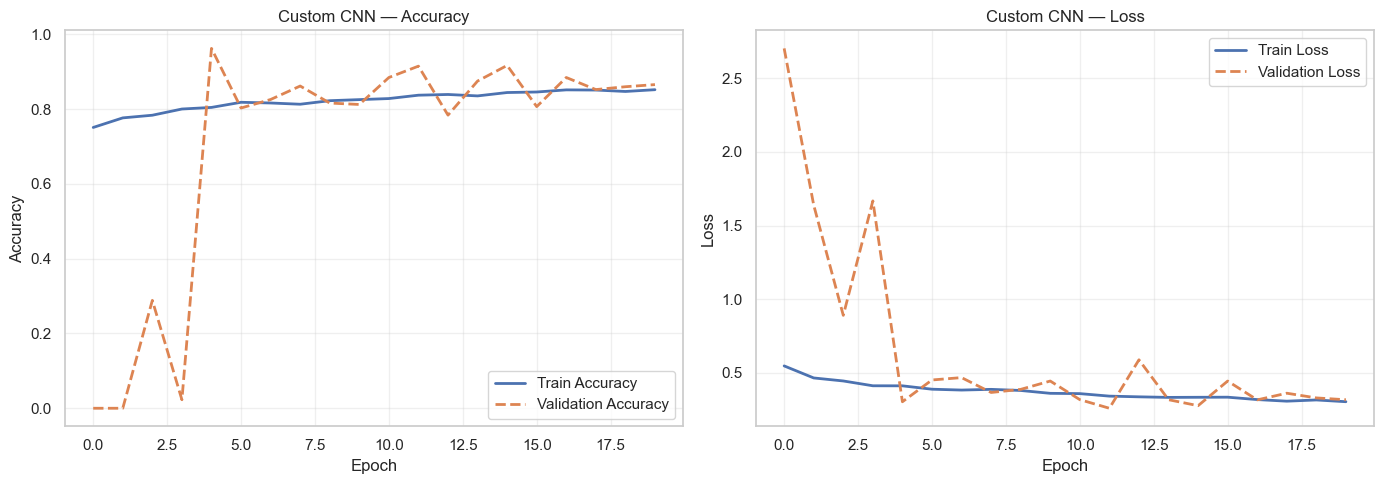

In [98]:
plot_learning_curves(cnn_history, 'Custom CNN')

# STEP 24: Evaluate the custom CNN model on the test data

In [ ]:
cnn_test_acc, cnn_fnr = evaluate_model(cnn_model, test_dataset, class_names, 'Custom CNN')


Custom CNN
Accuracy : 0.8136
Precision: 0.8293
Recall   : 0.8136
F1-Score : 0.8135

Classification Report:
              precision    recall  f1-score   support

      benign     0.9017    0.7389    0.8122       360
   malignant     0.7425    0.9033    0.8150       300

    accuracy                         0.8136       660
   macro avg     0.8221    0.8211    0.8136       660
weighted avg     0.8293    0.8136    0.8135       660



# STEP 25: Build the Transfer Learning Model (MobileNetV3Small)

In [105]:
def build_transfer_model(input_shape, augmentation, backbone='mobilenetv3small'):
    """
    Feature extraction model:
      1. Augment input (training only)
      2. Preprocess for MobileNetV3 (scales to [-1, 1])
      3. Frozen MobileNetV3Small backbone (no top)
      4. GlobalAveragePooling2D
      5. Dense classification head
    """
    if backbone == 'mobilenetv3small':
        base_model = tf.keras.applications.MobileNetV3Small(weights='imagenet', input_shape=input_shape, include_top=False,)
        preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
        model_name = 'mobilenetv3small_transfer'
    else:
        base_model = tf.keras.applications.MobileNetV2(weights='imagenet', input_shape=input_shape, include_top=False,)
        preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
        model_name = 'mobilenetv2_transfer'

    base_model.trainable = False
    print(f'Base model      : {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')

    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x)                     
    x = base_model(x, training=False)       
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name=model_name), base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation, backbone='mobilenetv3small')
tl_model.summary()


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model      : MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ MobileNetV3Small (Functional)        │ (None, 7, 7, 576)           │         939,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 576)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         147,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,087,346 (4.15 MB)

 Trainable params: 148,226 (579.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

# STEP 26: Compile and train the model (feature extraction phase)

In [106]:
TL_LR = 1e-4   # Lower LR for transfer learning head
tl_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=TL_LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'],)

tl_history = tl_model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS,callbacks=make_callbacks('tl_feature_extraction'), verbose=1,)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6863 - loss: 0.5898 - val_accuracy: 0.8330 - val_loss: 0.3577 - learning_rate: 1.0000e-04
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 434ms/step - accuracy: 0.7844 - loss: 0.4607 - val_accuracy: 0.8254 - val_loss: 0.3500 - learning_rate: 1.0000e-04
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 436ms/step - accuracy: 0.8100 - loss: 0.4114 - val_accuracy: 0.7970 - val_loss: 0.3863 - learning_rate: 1.0000e-04
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 435ms/step - accuracy: 0.8256 - loss: 0.3888 - val_accuracy: 0.8102 - val_loss: 0.3819 - learning_rate: 1.0000e-04
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 454ms/step - accuracy: 0.8294 - loss: 0.3761 - val_accuracy: 0.9013 - val_loss: 0.2403 - learning_rate: 1.0000e-04
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 432ms/step - accuracy: 0.8422 - loss: 0.3592 - val_accuracy: 0.8899 - val_loss: 0.2510 - learning_rate: 1.0000e-04
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 33s 508ms/step - accur

# STEP 27: Evaluate the Transfer Learning Model

MobileNetV3 TL -> val_loss: 0.1653
MobileNetV3 TL -> val_accuracy: 0.9374


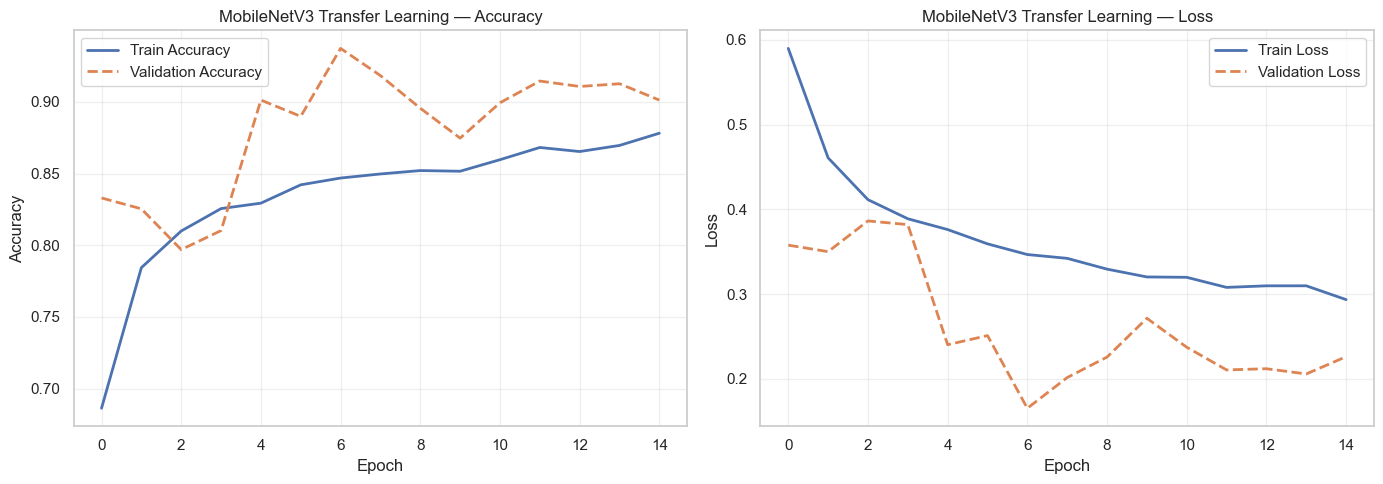

In [108]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_val_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

# STEP 28: Evaluate the Transfer Learning Model on the test set


MobileNetV3 Transfer
Accuracy : 0.8424
Precision: 0.8643
Recall   : 0.8424
F1-Score : 0.8420

Classification Report:
              precision    recall  f1-score   support

      benign     0.9507    0.7500    0.8385       360
   malignant     0.7606    0.9533    0.8462       300

    accuracy                         0.8424       660
   macro avg     0.8557    0.8517    0.8423       660
weighted avg     0.8643    0.8424    0.8420       660



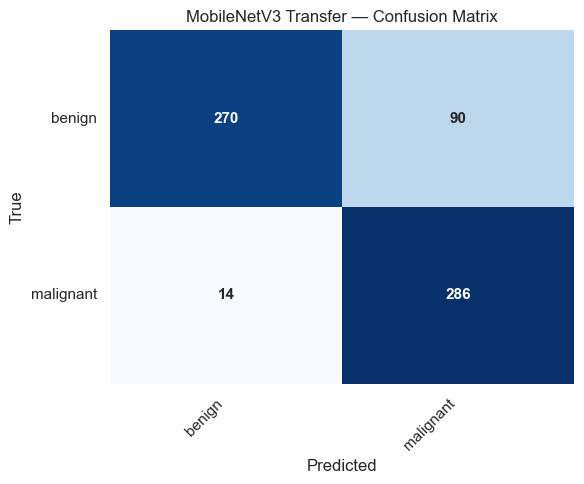

False Negative Rate (FNR): 0.0467
False Positive Rate (FPR): 0.2500


In [109]:
tl_test_acc, tl_fnr = evaluate_model(tl_model, test_dataset, class_names, 'MobileNetV3 Transfer')

# STEP 29: Fine-Tuning (unfreeze top layers)

In [110]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')

Trainable base layers after unfreezing: 20 / 157


# STEP 30: Recompile with a 10x smaller learning rate

In [113]:
FINETUNE_LR = TL_LR / 10
tl_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),loss='sparse_categorical_crossentropy', metrics=['accuracy'],)

# STEP 31: Continue training (fine-tuning phase)

In [114]:
ft_history = tl_model.fit(train_dataset, validation_data=val_dataset, epochs=15, callbacks=make_callbacks('tl_finetuned'), verbose=1,)

Epoch 1/15


C:\Users\HP\anaconda4\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


66/66 ━━━━━━━━━━━━━━━━━━━━ 51s 572ms/step - accuracy: 0.5815 - loss: 0.9099 - val_accuracy: 0.7780 - val_loss: 0.4395 - learning_rate: 1.0000e-05
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 34s 516ms/step - accuracy: 0.7322 - loss: 0.5553 - val_accuracy: 0.6546 - val_loss: 0.7384 - learning_rate: 1.0000e-05
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 33s 506ms/step - accuracy: 0.7919 - loss: 0.4478 - val_accuracy: 0.5996 - val_loss: 0.8704 - learning_rate: 1.0000e-05
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 33s 507ms/step - accuracy: 0.8171 - loss: 0.4147 - val_accuracy: 0.5806 - val_loss: 0.9468 - learning_rate: 1.0000e-05
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.8171 - loss: 0.4155
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
66/66 ━━━━━━━━━━━━━━━━━━━━ 34s 512ms/step - accuracy: 0.8171 - loss: 0.4155 - val_accuracy: 0.5882 - val_loss: 0.9191 - learning_rate: 1.0000e-05
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 33s 507ms/step - accuracy: 0.8341 - 

# STEP 32: Visualise fine-tuning learning curves

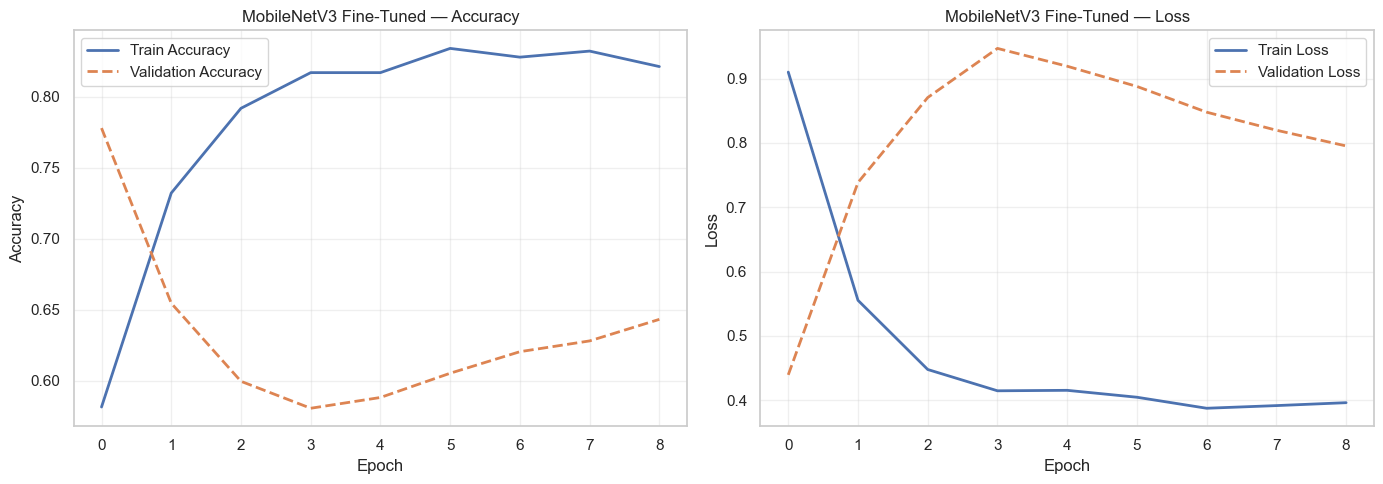

In [115]:
plot_learning_curves(ft_history, 'MobileNetV3 Fine-Tuned')

# STEP 33: Evaluate the fine-tuned model on the test set


MobileNetV3 Fine-Tuned
Accuracy : 0.8167
Precision: 0.8196
Recall   : 0.8167
F1-Score : 0.8149

Classification Report:
              precision    recall  f1-score   support

      benign     0.7980    0.8889    0.8410       360
   malignant     0.8456    0.7300    0.7835       300

    accuracy                         0.8167       660
   macro avg     0.8218    0.8094    0.8123       660
weighted avg     0.8196    0.8167    0.8149       660



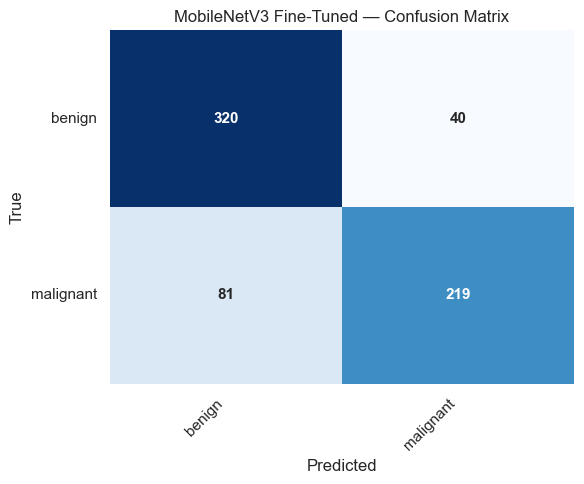

False Negative Rate (FNR): 0.2700
False Positive Rate (FPR): 0.1111


In [116]:
ft_test_acc, ft_fnr = evaluate_model(tl_model, test_dataset, class_names, 'MobileNetV3 Fine-Tuned')

# STEP 34: Side-by-side model comparison

In [117]:
results = {
    'Custom CNN': {'acc': cnn_test_acc, 'fnr': cnn_fnr, 'params': cnn_model.count_params()},
    'MobileNetV3 (TL)': {'acc': tl_test_acc, 'fnr': tl_fnr, 'params': tl_model.count_params()},
    'MobileNetV3 (FT)': {'acc': ft_test_acc, 'fnr': ft_fnr, 'params': tl_model.count_params()},
}

print(f'{"Model":<22} {"Test Acc":>10} {"FNR":>10} {"Params":>14}')
print('-' * 60)
for name, vals in results.items():
    print(f'{name:<22} {vals["acc"]:>10.4f} {vals["fnr"]:>10.4f} {vals["params"]:>14,}')

Model                    Test Acc        FNR         Params
------------------------------------------------------------
Custom CNN                 0.8136     0.0967        322,338
MobileNetV3 (TL)           0.8424     0.0467      1,087,346
MobileNetV3 (FT)           0.8167     0.2700      1,087,346


# STEP 35: Visualise model comparison

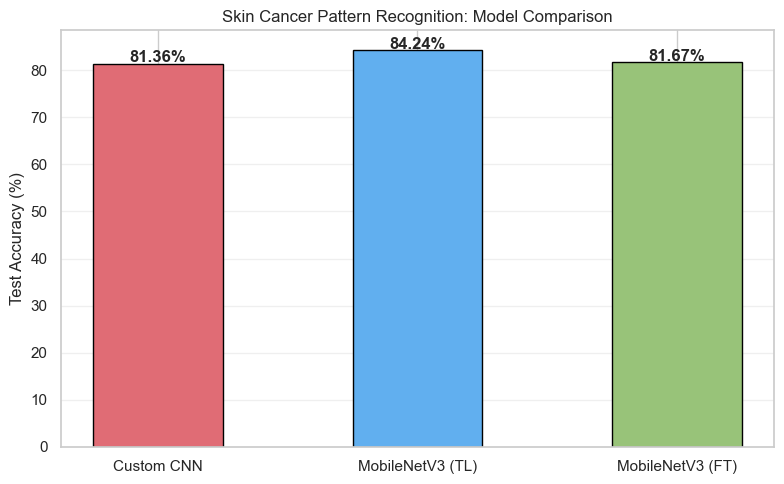

In [118]:
labels = list(results.keys())
accs = [v['acc'] * 100 for v in results.values()]
colors = ['#e06c75', '#61afef', '#98c379']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='black', width=0.5)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Skin Cancer Pattern Recognition: Model Comparison')
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f'{acc:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(results_dir + 'model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# STEP 36: Predict on a new image

In [121]:
def predict_image(img_path, models_dict, class_names, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    """Load an image file and classify it with each model in models_dict."""
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)   # [0, 255] float32
    img_array = np.expand_dims(img_array, axis=0)   # (1, H, W, 3)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    for name, model in models_dict.items():
        probs = model.predict(img_array, verbose=0)[0]
        pred_idx = np.argmax(probs)
        print(f'{name:<22} -> {class_names[pred_idx]} ({probs[pred_idx] * 100:.2f}% confidence)')

# STEP 37: Save the best-performing model for deployment

In [122]:
best_name = min(results, key=lambda k: (results[k]['fnr'], -results[k]['acc']))
print(f'Best model for deployment: {best_name}')

best_model = tl_model if 'MobileNetV3' in best_name else cnn_model
best_model.save('models/skin_lesion_classifier.keras')
print('Saved deployment model to models/skin_lesion_classifier.keras')

cnn_model.save('models/custom_cnn.keras')
tl_model.save('models/mobilenetv3_final.keras')
print('Also saved: models/custom_cnn.keras and models/mobilenetv3_final.keras')

Best model for deployment: MobileNetV3 (TL)
Saved deployment model to models/skin_lesion_classifier.keras
Also saved: models/custom_cnn.keras and models/mobilenetv3_final.keras
